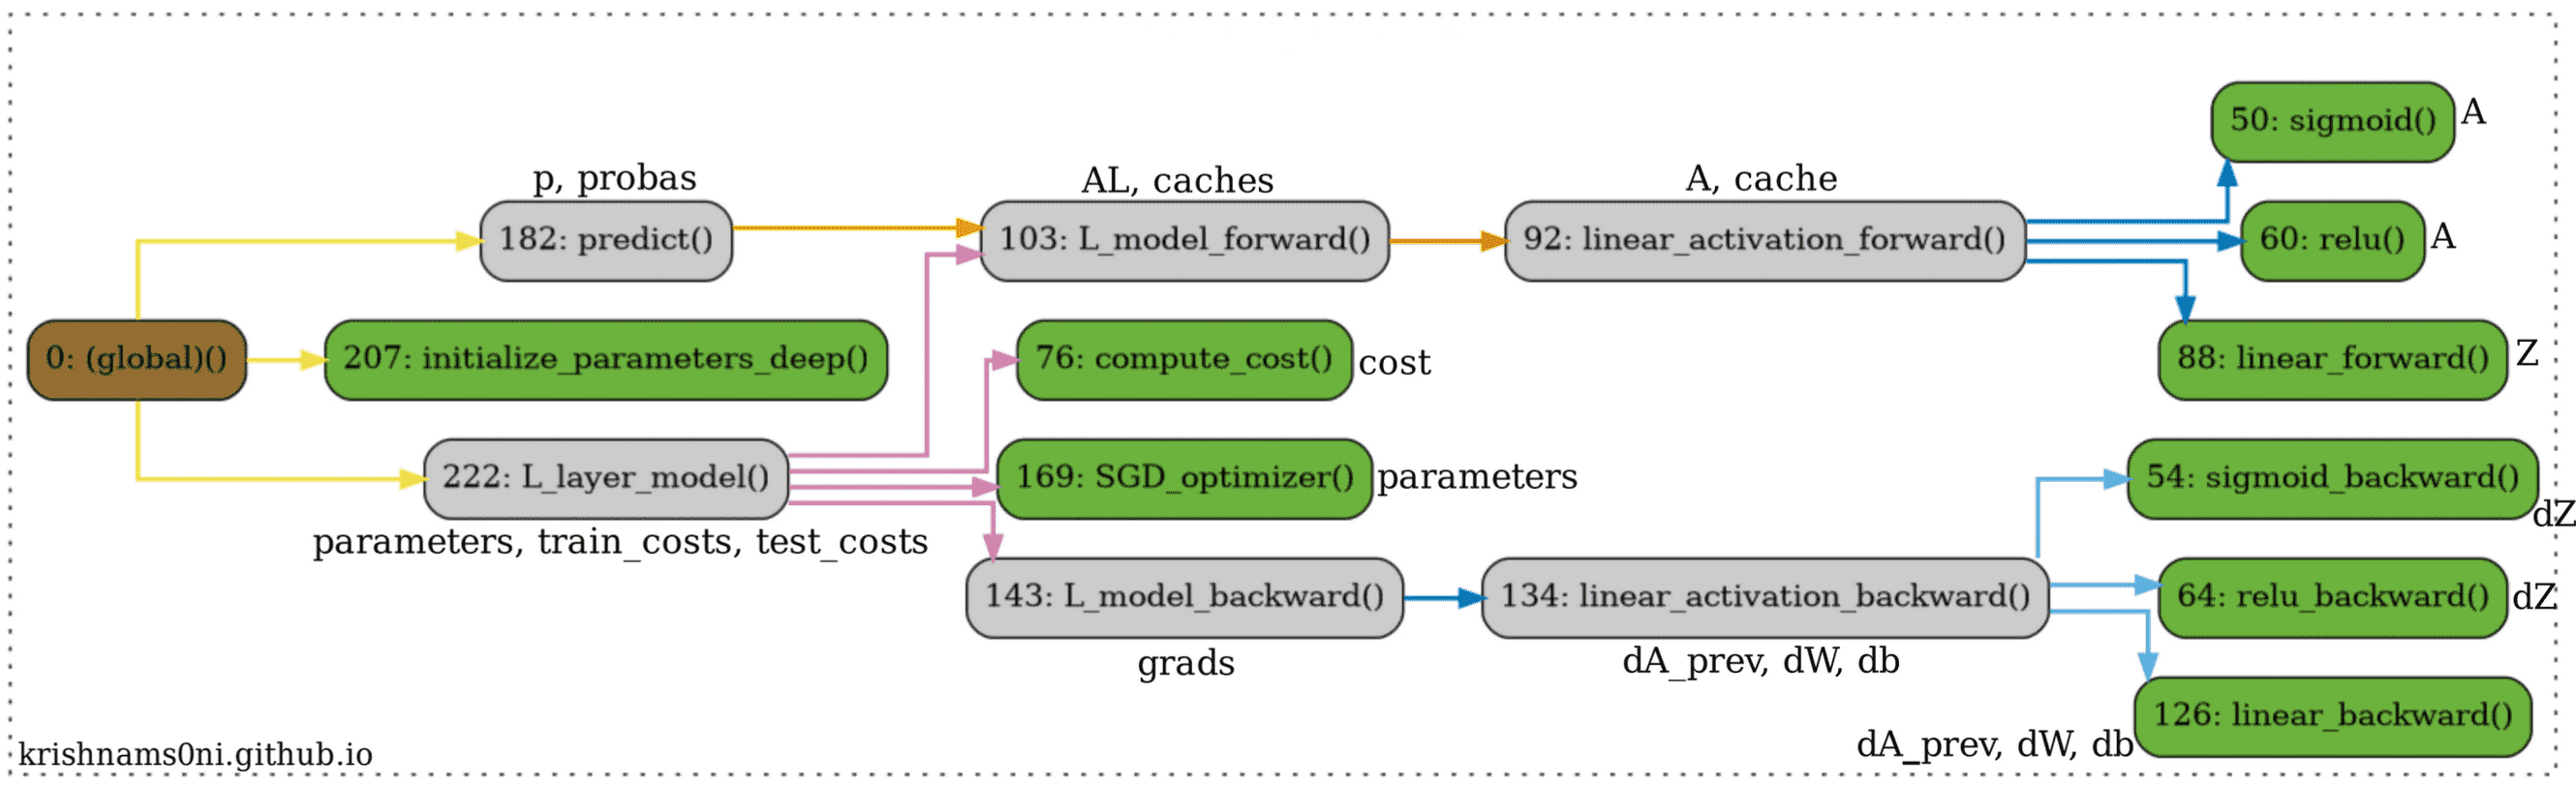

Notes:
- the variables around the functions are the return values of the functions
- parameters have been initialized using [Xavier initialization](https://www.deeplearning.ai/ai-notes/initialization/index.html)
- ignore the numbers in the boxes in the diagram above - they are the line numbers of the code, and don't matter
- you can see this same algorithm implemented on another dataset [here](https://www.kaggle.com/code/krishnams0ni/stroke-prediction-using-pure-python-93-accuracy)

### Loading data

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

np.random.seed(42)

dataset = pd.read_csv('data/train.csv')

X = dataset.drop(columns=['target'])
y = dataset['target']

X = X.fillna(X.mean())

scaler = StandardScaler()
X = scaler.fit_transform(X)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=21)

train_x = train_x.T
test_x = test_x.T

train_y = train_y.values.reshape(1, -1)
test_y = test_y.values.reshape(1, -1)

print("train_x's shape: " + str(train_x.shape))
print("train_y's shape: " + str(train_y.shape))
print("test_x's shape: " + str(test_x.shape))
print("test_y's shape: " + str(test_y.shape))

train_x's shape: (16, 901)
train_y's shape: (1, 901)
test_x's shape: (16, 387)
test_y's shape: (1, 387)


### Activation Functions with Gradients

In [6]:
def sigmoid(Z):
    A = 1 / (1 + np.exp(-Z))
    return A

def sigmoid_backward(dA, cache):
    Z = cache
    s = 1 / (1 + np.exp(-Z))
    dZ = dA * s * (1 - s)
    return dZ

def relu(Z):
    A = np.maximum(0, Z)
    return A

def relu_backward(dA, cache):
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

### Binary Cross Entropy Cost Function

In [7]:
def compute_cost(AL, Y):
    m = Y.shape[1]
    cost = (1. / m) * (-np.dot(Y, np.log(AL).T) - np.dot(1 - Y, np.log(1 - AL).T))
    cost = np.squeeze(cost)
    return cost

### Forward Propagation

In [8]:
def linear_forward(A, W, b):
    Z = W.dot(A) + b
    return Z

def linear_activation_forward(A_prev, W, b, activation):
    linear_cache = A_prev, W, b
    Z = linear_forward(A_prev, W, b)
    activation_cache = Z
    if activation == "sigmoid":
        A = sigmoid(Z)
    else:
        A = relu(Z)
    cache = (linear_cache, activation_cache)
    return A, cache

def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(A_prev,
            parameters['W' + str(l)], parameters['b' + str(l)], activation="relu")
        caches.append(cache)
    
    AL, cache = linear_activation_forward(A,
        parameters['W' + str(L)], parameters['b' + str(L)], activation="sigmoid")
    caches.append(cache)
    
    return AL, caches

### Backpropagation

In [9]:
def linear_backward(dZ, cache):
    A_prev, W, b = cache
    m = A_prev.shape[1]
    dW = 1. / m * np.dot(dZ, A_prev.T)
    db = 1. / m * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    return dA_prev, dW, db

def linear_activation_backward(dA, cache, activation):
    linear_cache, activation_cache = cache
    if activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
    else:
        dZ = relu_backward(dA, activation_cache)
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    return dA_prev, dW, db

def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    
    dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
    
    current_cache = caches[L - 1]
    grads["dA" + str(L - 1)], grads["dW" + str(L)], grads[
        "db" + str(L)] = linear_activation_backward(dAL, current_cache, activation="sigmoid")
    
    for l in reversed(range(L - 1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(
            grads["dA" + str(l + 1)], current_cache, activation="relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp
    return grads

### Gradient Descent

In [10]:
def SGD_optimizer(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(L):
        parameters["W" + str(l + 1)] = parameters["W" + str(l + 1)] - learning_rate * grads["dW" + str(l + 1)]
        parameters["b" + str(l + 1)] = parameters["b" + str(l + 1)] - learning_rate * grads["db" + str(l + 1)]
    return parameters

### Predict

In [11]:
def predict(X, y, parameters):
    m = X.shape[1]
    p = np.zeros((1, m))
    
    probas, caches = L_model_forward(X, parameters)
    for i in range(0, probas.shape[1]):
        p[0, i] = probas[0, i] > 0.5
    return p, probas

### L layer model

In [43]:
n_x = 16
n_h = 15
n_y = 1
layers_dims = (n_x, n_h, n_y)

In [44]:
def initialize_parameters_deep(layer_dims):
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims)
    
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l - 1]) * np.sqrt(1 / layer_dims[l - 1])
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

In [45]:
def L_layer_model(X, Y, layers_dims, optimizer, learning_rate, num_iterations, print_cost=True):
    np.random.seed(1)
    train_costs = []
    test_costs = []
    parameters = initialize_parameters_deep(layers_dims)
    
    for i in range(0, num_iterations):
        AL, caches = L_model_forward(X, parameters)
        train_cost = compute_cost(AL, Y)
        test_cost = compute_cost(L_model_forward(test_x, parameters)[0], test_y)
        grads = L_model_backward(AL, Y, caches)
        parameters = optimizer(parameters, grads, learning_rate)
        if print_cost and i == 0 or i % 1000 == 0 or i == num_iterations - 1:
            print("Cost after iteration {}: {} {}".format(i, np.round(np.squeeze(train_cost), 4), np.round(np.squeeze(test_cost), 4)))
        if i == 0 or i % 10 == 0 or i == num_iterations - 1:
            train_costs.append(train_cost)
            test_costs.append(test_cost)
    return parameters, train_costs, test_costs

In [70]:
%%time
parameters, train_costs, test_costs = L_layer_model(train_x, train_y, layers_dims, optimizer=SGD_optimizer, learning_rate=0.001, num_iterations=160000)

Cost after iteration 0: 0.7497 0.7378
Cost after iteration 1000: 0.5086 0.4893
Cost after iteration 2000: 0.4218 0.4008
Cost after iteration 3000: 0.3833 0.3622
Cost after iteration 4000: 0.3642 0.3431
Cost after iteration 5000: 0.3538 0.3327
Cost after iteration 6000: 0.3476 0.3263
Cost after iteration 7000: 0.3436 0.3222
Cost after iteration 8000: 0.3408 0.3193
Cost after iteration 9000: 0.3387 0.3171
Cost after iteration 10000: 0.3371 0.3154
Cost after iteration 11000: 0.3358 0.314
Cost after iteration 12000: 0.3347 0.3128
Cost after iteration 13000: 0.3337 0.3117
Cost after iteration 14000: 0.3328 0.3106
Cost after iteration 15000: 0.332 0.3097
Cost after iteration 16000: 0.3313 0.3089
Cost after iteration 17000: 0.3305 0.3081
Cost after iteration 18000: 0.3298 0.3073
Cost after iteration 19000: 0.3291 0.3066
Cost after iteration 20000: 0.3286 0.306
Cost after iteration 21000: 0.328 0.3054
Cost after iteration 22000: 0.3275 0.3049
Cost after iteration 23000: 0.327 0.3044
Cost after

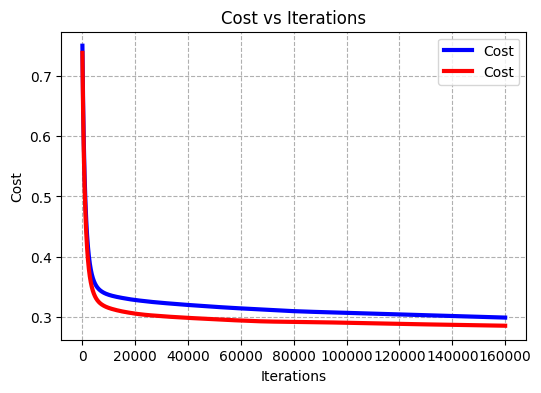

In [71]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
iterations = range(1, len(train_costs) * 10, 10)
plt.plot(iterations, train_costs, color='blue', linewidth=3, label='Cost')
plt.plot(iterations, test_costs, color='red', linewidth=3, label='Cost')
plt.xlabel('Iterations', fontsize=10)
plt.ylabel('Cost', fontsize=10)
plt.title('Cost vs Iterations', fontsize=12)
plt.grid(True, linestyle='--')
plt.legend(loc='upper right', fontsize=10)
plt.show()

In [72]:
pred_train = predict(train_x, train_y, parameters)
m = train_x.shape[1]
print("Training accuracy: " + str(np.sum((pred_train == train_y) / m) * 100)[:7])

pred_test = predict(test_x, test_y, parameters)
m = test_x.shape[1]
print("Test accuracy: " + str(np.sum((pred_test == test_y) / m) * 100)[:7])

Training accuracy: 86.7924
Test accuracy: 88.6304


Train F1 Score: 0.8841285296981499
Test F1 Score: 0.9051724137931034


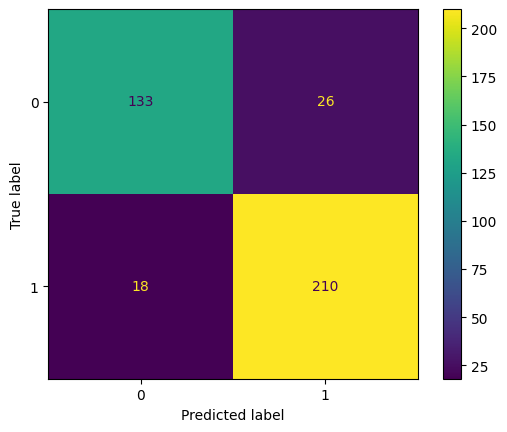

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

print("Train F1 Score:", f1_score(train_y[0], predict(train_x, train_y, parameters)[0][0]))
print("Test F1 Score:", f1_score(test_y[0], pred_test[0][0]))
conf_mat = confusion_matrix(test_y[0], pred_test[0][0])
cm_plot = ConfusionMatrixDisplay(conf_mat)
cm_plot.plot()
plt.show()

In [74]:
b = pd.DataFrame(test_x.T, columns=dataset.columns[:-1])
b[(pred_test[0]!=test_y).T]

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4
0,0.346049,0.276883,-0.022306,0.747600,-0.598941,0.375654,-0.356578,0.493668,0.323696,-0.794137,-0.546643,0.519729,-0.507640,0.265430,0.492003,-0.606159
14,0.835964,1.594265,0.937730,0.411136,0.206071,0.834635,0.091557,0.843311,-0.997751,0.010547,-1.381741,0.005411,-0.640913,-0.639796,-0.024882,0.227334
25,0.679359,-0.283938,1.682901,-0.340226,1.017197,0.689701,0.547914,0.514073,0.759657,1.239236,0.344951,-0.956339,-0.107819,-1.243280,-0.948234,0.668712
41,0.643350,-0.021907,0.452281,0.280220,0.087867,0.656145,0.208730,0.599068,0.127998,-0.127423,-0.077583,0.325995,-0.640913,-0.639796,0.296771,0.637185
47,0.322147,-0.616308,0.200976,0.153367,0.073601,0.352830,0.545859,0.149932,1.067736,-0.143407,0.822082,0.219902,-0.374366,-0.338054,0.189553,0.351472
60,0.228634,-0.527331,0.237840,-0.050243,0.263135,0.263135,0.371127,0.112574,1.073549,0.079532,0.585178,0.058458,-0.241093,-0.338054,0.027926,0.515018
68,-0.512408,-0.896242,-0.859323,-0.479527,0.098057,-0.471985,0.899433,-0.805642,-0.309901,-0.116486,0.993469,0.383654,0.025454,-0.036312,0.354380,0.798760
108,1.004132,-0.440816,1.548370,0.056026,0.711497,0.988492,0.784316,0.759161,1.288623,0.707127,0.793596,-0.458166,-0.507640,-1.243280,-0.476157,0.743588
116,0.122860,-0.407008,0.128618,-0.187346,0.326313,0.160889,0.525302,-0.047673,1.054173,0.158613,0.305546,0.049232,-0.241093,-0.338054,0.018325,0.684475
123,0.325096,-0.513452,1.294145,-0.171144,0.778751,0.355648,-0.362745,0.473110,-0.048324,0.814390,0.606067,-0.972483,0.158728,-0.639796,-0.965837,-0.273156


In [75]:
test_data = pd.read_csv("data/test.csv")
X_test = scaler.transform(test_data)

In [77]:
test_x = X_test.T

In [78]:
test_x

array([[ 1.01817831, -0.1097976 , -0.42184378, ...,  0.41333179,
         0.47091404, -2.21690472],
       [ 1.17197823,  1.96525483,  0.6347365 , ..., -0.59671567,
        -0.71420613, -1.05171762],
       [ 0.01342511, -0.23820434, -0.15738918, ...,  1.05895292,
         0.30575226, -2.02467297],
       ...,
       [-0.03631212, -0.03631212, -0.03631212, ..., -0.63979614,
        -0.63979614,  1.17065591],
       [ 1.33054092,  0.14634585, -0.3705393 , ..., -0.63618306,
         0.25516377, -0.9642371 ],
       [-0.02685176, -0.07414218,  0.01255693, ..., -0.26527429,
         0.81452365,  0.22733426]])

In [79]:
preds = predict(test_x, None, parameters)
preds

(array([[0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1.,
         0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0.,
         0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
         1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1.,
         1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1.,
         1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
         1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0.,
         1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
         0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0.,
         0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 1., 0., 0.,
         1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 0.,
         0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0.

In [83]:
preds_df = pd.DataFrame(preds[0].T)
preds_df.to_csv("results/answer_1.csv", index=False)